In [40]:
import pandas as pd

In [41]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [42]:
train

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


## EDA

In [43]:
cat_features = train.select_dtypes(include=['object']).columns.tolist()
unique_counts = train[cat_features].nunique().sort_values(ascending=False)
print("Количество уникальных значений в категориальных признаках:")
print(unique_counts)
print("\nПримеры значений для признаков:")
display(train[cat_features].head())

C:\Users\stla7\AppData\Local\Temp\ipykernel_18312\4278267702.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = train.select_dtypes(include=['object']).columns.tolist()


Количество уникальных значений в категориальных признаках:
PaymentMethod       4
OnlineBackup        3
InternetService     3
OnlineSecurity      3
TechSupport         3
StreamingTV         3
DeviceProtection    3
MultipleLines       3
StreamingMovies     3
Contract            3
Dependents          2
PhoneService        2
gender              2
Partner             2
PaperlessBilling    2
Churn               2
dtype: int64

Примеры значений для признаков:


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,Yes,Yes,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,No
1,Male,Yes,Yes,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),No
2,Male,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
3,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [44]:
display(train.describe(include='all'))

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194,594194.000000,594194,594194,594194.000000,594194,594194,594194,594194,...,594194,594194,594194,594194,594194,594194,594194,594194.000000,594194.000000,594194
unique,NaN,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,NaN,Female,NaN,Yes,No,NaN,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,NaN,298738,NaN,309554,414362,NaN,557893,283384,272386,289474,...,247377,288571,240301,241435,298918,365579,215372,NaN,NaN,460377
mean,297096.500000,NaN,0.114102,NaN,NaN,36.577258,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.866223,2494.377057,NaN
std,171529.177263,NaN,0.317936,NaN,NaN,25.061922,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.067444,2353.916710,NaN
min,0.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,148548.250000,NaN,0.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.900000,639.650000,NaN
50%,297096.500000,NaN,0.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.100000,1433.650000,NaN
75%,445644.750000,NaN,0.000000,NaN,NaN,62.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.800000,4263.800000,NaN


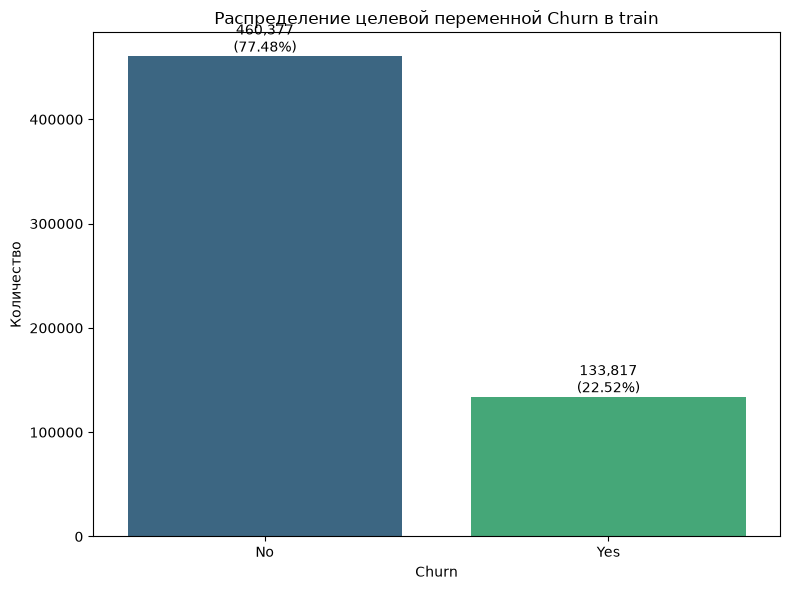

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# График распределения целевой переменной Churn в train
order = train['Churn'].value_counts().index.tolist()
counts = train['Churn'].value_counts().reindex(order)
percentages = train['Churn'].value_counts(normalize=True).reindex(order) * 100

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=train,
    x='Churn',
    hue='Churn',
    order=order,
    palette='viridis',
    legend=False,
)

for i, class_name in enumerate(order):
    count = counts.loc[class_name]
    pct = percentages.loc[class_name]
    ax.text(
        i,
        count,
        f'{count:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
    )

plt.title('Распределение целевой переменной Churn в train')
plt.xlabel('Churn')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [46]:
print("Пропуски в обучающей выборке (train):")
display(train.isnull().sum().sort_values(ascending=False))

print("\nПропуски в тестовой выборке (test):")
display(test.isnull().sum().sort_values(ascending=False))

Пропуски в обучающей выборке (train):


id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Пропуски в тестовой выборке (test):


id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

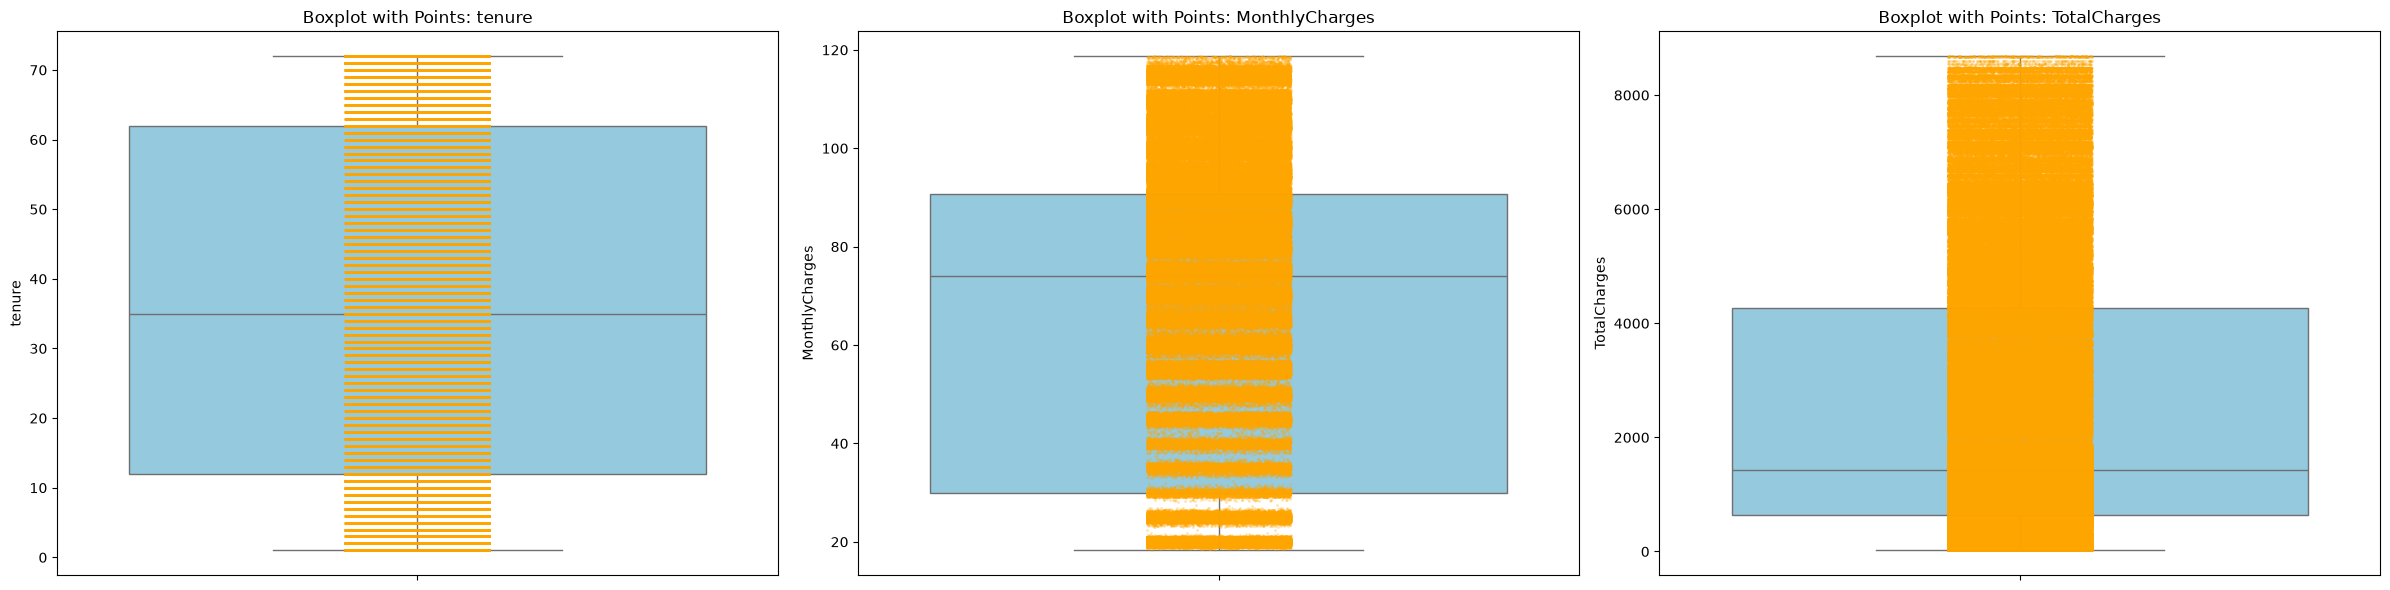

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include=['number']).columns.tolist()
num_cols = num_cols[2:len(num_cols)]
# 2. BoxPlot с точками (stripplot) для визуализации выбросов
fig, axes = plt.subplots(1, len(num_cols), figsize=(24, 6))
for i, col in enumerate(num_cols):
    # Строим основной боксплот
    sns.boxplot(y=train[col], ax=axes[i], color='skyblue', showfliers=False)
    # Накладываем точки (stripplot) с прозрачностью для плотности
    sns.stripplot(y=train[col], ax=axes[i], color='orange', size=2, jitter=True, alpha=0.3)
    axes[i].set_title(f'Boxplot with Points: {col}')

plt.tight_layout()
plt.show()

In [48]:
feature_cols = [
    col for col in train.columns
    if col not in ['id', 'Churn']
]

duplicates = train[
    train.duplicated(subset=feature_cols, keep=False)
]

print(
    'Количество строк с повторяющимися признаками:',
    train.duplicated(subset=feature_cols).sum()
)

display(duplicates.head(10))

conflicts = (
    train.groupby(feature_cols, dropna=False)['Churn']
    .nunique()
)

conflicts = conflicts[conflicts > 1]

print('Одинаковые X, но разный Churn:', len(conflicts))



# ДУБЛИКАТОВ ВООБЩЕ НЕТ!

Количество строк с повторяющимися признаками: 0


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Одинаковые X, но разный Churn: 0


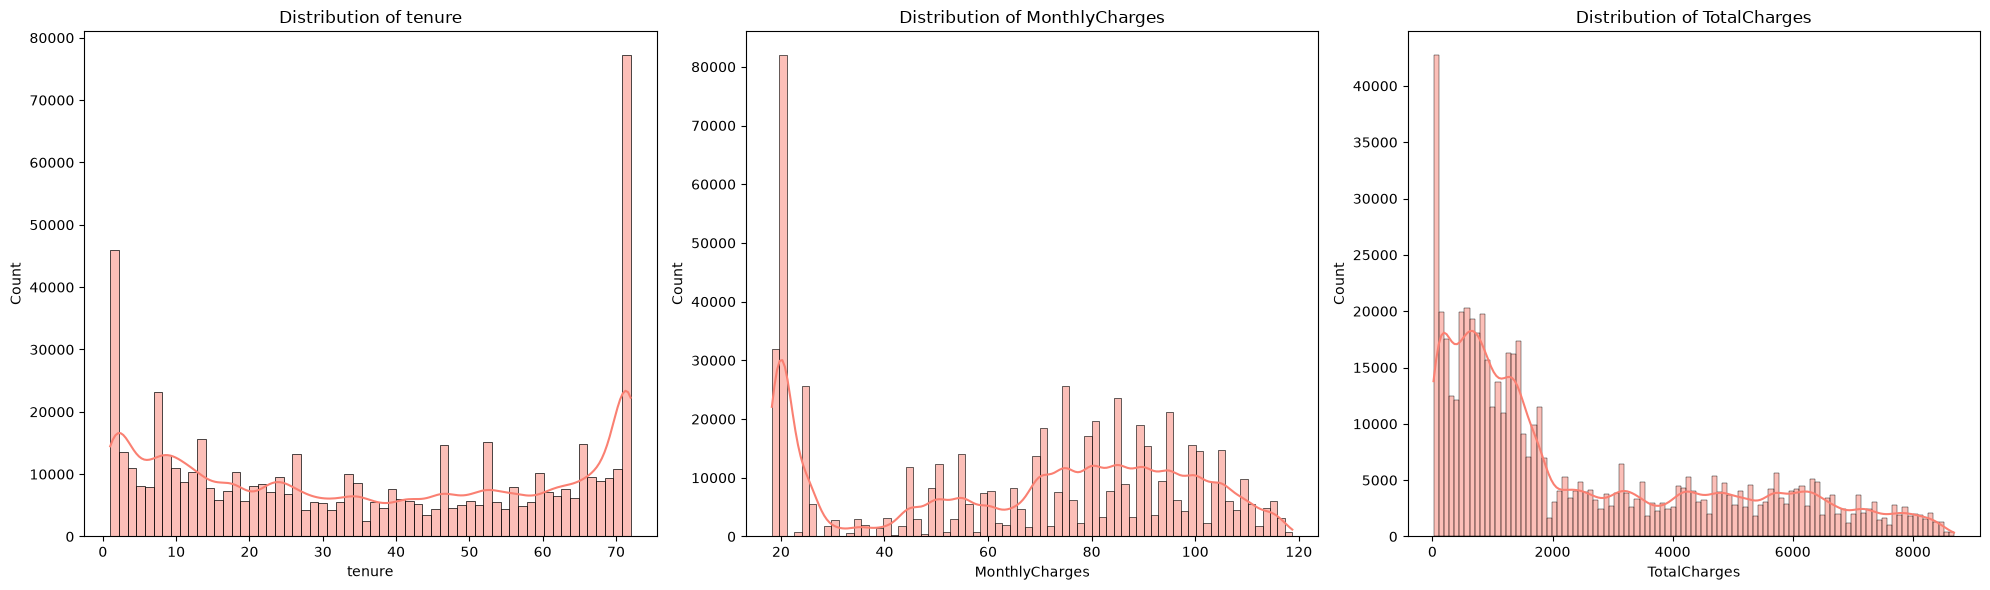

In [49]:
# Функции распределения (гистограммы + KDE)
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))
for i, col in enumerate(num_cols):
    sns.histplot(train[col], kde=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

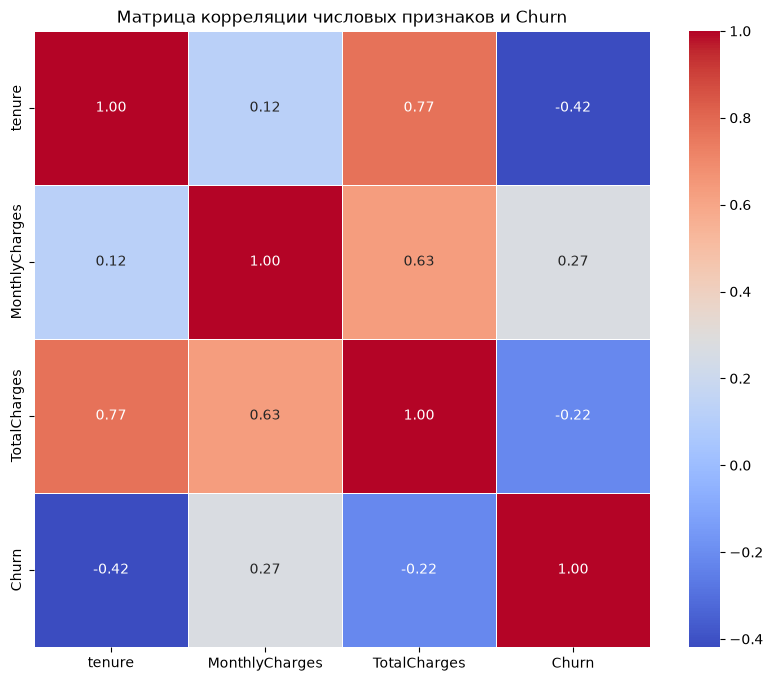

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Вычисляем матрицу корреляции для числовых столбцов
corr_matrix = train[num_cols + ['Churn']].replace({'Yes': 1, 'No': 0}).corr()

# Визуализируем с помощью heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Матрица корреляции числовых признаков и Churn')
plt.show()

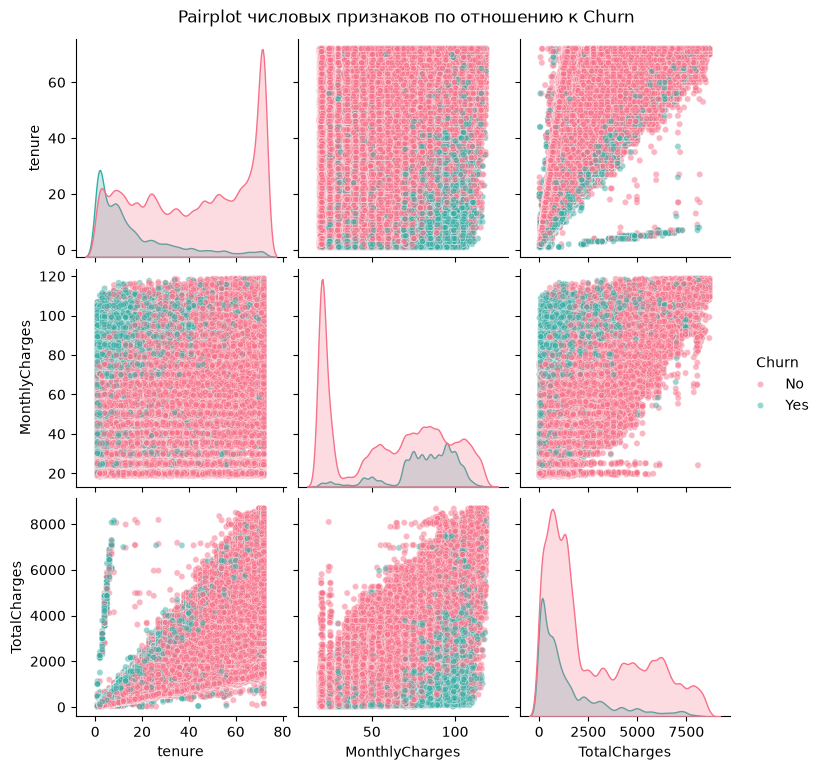

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Строим pairplot для числовых признаков с разделением по Churn
sns.pairplot(train[num_cols + ['Churn']], hue='Churn', palette='husl', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot числовых признаков по отношению к Churn', y=1.02)
plt.show()

In [52]:
# Список признаков для анализа (категориальные + SeniorCitizen)
features_to_analyze = cat_features + ['SeniorCitizen']
if 'Churn' in features_to_analyze:
    features_to_analyze.remove('Churn')

print("Анализ влияния признаков на Churn (доля в % по строке):")
for col in features_to_analyze:
    ct = pd.crosstab(train[col], train['Churn'], normalize='index') * 100
    print(f"\n--- {col} ---")
    display(ct.round(2))

Анализ влияния признаков на Churn (доля в % по строке):

--- gender ---


Churn,No,Yes
gender,,
Female,77.20,22.80
Male,77.77,22.23



--- Partner ---


Churn,No,Yes
Partner,,
No,67.54,32.46
Yes,86.62,13.38



--- Dependents ---


...

Churn,No,Yes
PaperlessBilling,,
No,92.54,7.46
Yes,68.06,31.94



--- PaymentMethod ---


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),92.29,7.71
Credit card (automatic),93.07,6.93
Electronic check,51.09,48.91
Mailed check,92.03,7.97



--- SeniorCitizen ---


Churn,No,Yes
SeniorCitizen,,
0,81.02,18.98
1,49.97,50.03


Наиболее выраженная связь с Churn наблюдается у Contract, PaymentMethod, InternetService, SeniorCitizen, OnlineSecurity и TechSupport. Клиенты с month-to-month контрактом, Electronic check, Fiber optic и SeniorCitizen характеризуются значительно более высоким churn rate. Наличие долгосрочного контракта, OnlineSecurity и TechSupport связано с более низким churn. gender практически не демонстрирует связи с целевой переменной.

# 3. Подготовка данных

In [53]:
# 1. Удаление строк с пропущенным Churn в train
train = train.dropna(subset=['Churn'])

# Определяем числовые и категориальные признаки (исключая ID и Target)
num_features = train.select_dtypes(include=['number']).columns.tolist()
if 'id' in num_features: num_features.remove('id')
if 'SeniorCitizen' in num_features: num_features.remove('SeniorCitizen') # Часто его считают категориальным, но оставим в списке для заполнения

cat_features_fill = train.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in cat_features_fill: cat_features_fill.remove('Churn')

# 2. Обработка числовых признаков (Медиана)
for col in num_features:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# 3. Обработка категориальных признаков (Мода)
for col in cat_features_fill + ['SeniorCitizen']:
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)

print("Обработка пропусков завершена.")
print(f"Размер train после очистки Churn: {train.shape}")
print(f"Осталось пропусков в train: {train.isnull().sum().sum()}")
print(f"Осталось пропусков в test: {test.isnull().sum().sum()}")

C:\Users\stla7\AppData\Local\Temp\ipykernel_18312\480894736.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_fill = train.select_dtypes(include=['object']).columns.tolist()


Обработка пропусков завершена.
Размер train после очистки Churn: (594194, 21)
Осталось пропусков в train: 0
Осталось пропусков в test: 0


In [54]:
X = train.drop(columns=['id', 'Churn']).copy()
y = train['Churn'].copy()

if y.dtype == 'object':
    mapped_y = y.map({'No': 0, 'Yes': 1})
    if mapped_y.notna().all():
        y = mapped_y.astype(int)

print("Размерность X:", X.shape)
print("Размерность y:", y.shape)
print("Распределение target:")
display(y.value_counts(dropna=False))

Размерность X: (594194, 19)
Размерность y: (594194,)
Распределение target:


Churn
No     460377
Yes    133817
Name: count, dtype: int64

# Feature Engineering

На этом этапе только создаём разные наборы признаков. Модель здесь не обучается: это нужно, чтобы не смешивать подготовку данных, подбор гиперпараметров и CV-оценку.

Наборы признаков:

1. `X_base_no_features` — базовый набор без новых фичей. Это исходный `X` после подготовки данных: без `id` и без целевой переменной `Churn`.
2. `FE_1_num_extra_services` — базовый набор + `num_extra_services`. Новая фича считает, сколько дополнительных сервисов подключено у клиента: `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
3. `FE_2_charges_tenure` — базовый набор + признаки по сроку жизни и платежам: `avg_monthly_charge`, `tenure_category`, `total_charges_category`.
4. `FE_all_without_gender` — общий feature engineering: удаляем `gender`, добавляем `num_extra_services`, `avg_monthly_charge`, `tenure_category`, `total_charges_category`.

In [55]:
import numpy as np
import pandas as pd

X_base = X.copy()


def make_fe_1_services(X_input):
    """FE #1: количество подключенных дополнительных сервисов."""
    X_fe = X_input.copy()
    service_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]

    missing_cols = [col for col in service_cols if col not in X_fe.columns]
    if missing_cols:
        raise ValueError("Missing columns for FE #1: " + ", ".join(missing_cols))

    X_fe["num_extra_services"] = X_fe[service_cols].eq("Yes").sum(axis=1)
    return X_fe


def make_fe_2_charges_tenure(X_input):
    """FE #2: признаки по tenure и charges."""
    X_fe = X_input.copy()

    required_cols = ["TotalCharges", "tenure", "MonthlyCharges"]
    missing_cols = [col for col in required_cols if col not in X_fe.columns]
    if missing_cols:
        raise ValueError("Missing columns for FE #2: " + ", ".join(missing_cols))

    X_fe["avg_monthly_charge"] = np.where(
        X_fe["tenure"] != 0,
        X_fe["TotalCharges"] / X_fe["tenure"],
        X_fe["MonthlyCharges"],
    )

    tenure_bins = [0, 6, 12, 18, 36, 48, np.inf]
    tenure_labels = ["0-6", "7-12", "13-18", "19-36", "37-48", "49+"]
    X_fe["tenure_category"] = pd.cut(
        X_fe["tenure"],
        bins=tenure_bins,
        labels=tenure_labels,
        right=True,
        include_lowest=True,
    )

    X_fe["total_charges_category"] = pd.qcut(
        X_fe["TotalCharges"],
        q=3,
        labels=["low", "medium", "high"],
    )

    return X_fe


def make_fe_all_without_gender(X_input):
    """FE all: удалить gender и добавить все выбранные новые признаки."""
    X_fe = X_input.copy()

    X_fe = X_fe.drop(columns=["gender"])

    X_fe = make_fe_1_services(X_fe)
    X_fe = make_fe_2_charges_tenure(X_fe)
    return X_fe


def make_test_feature_sets(test_df):
    """Создаём такие же feature-наборы для test, как для train."""
    X_test_base = test_df.drop(columns=["id"], errors="ignore").copy()
    return {
        "X_base_no_features": X_test_base,
        "FE_1_num_extra_services": make_fe_1_services(X_test_base),
        "FE_2_charges_tenure": make_fe_2_charges_tenure(X_test_base),
        "FE_all_without_gender": make_fe_all_without_gender(X_test_base),
    }


X_fe_1 = make_fe_1_services(X_base)
X_fe_2 = make_fe_2_charges_tenure(X_base)
X_fe_all_without_gender = make_fe_all_without_gender(X_base)

feature_sets = {
    "X_base_no_features": X_base,
    "FE_1_num_extra_services": X_fe_1,
    "FE_2_charges_tenure": X_fe_2,
    "FE_all_without_gender": X_fe_all_without_gender,
}

test_feature_sets = make_test_feature_sets(test)

for feature_set_name, X_set in feature_sets.items():
    print(f"{feature_set_name}: {X_set.shape[1]} признаков, train_shape={X_set.shape}, test_shape={test_feature_sets[feature_set_name].shape}")

X_base_no_features: 19 признаков, train_shape=(594194, 19), test_shape=(254655, 19)
FE_1_num_extra_services: 20 признаков, train_shape=(594194, 20), test_shape=(254655, 20)
FE_2_charges_tenure: 22 признаков, train_shape=(594194, 22), test_shape=(254655, 22)
FE_all_without_gender: 22 признаков, train_shape=(594194, 22), test_shape=(254655, 22)


## Общие функции для моделей


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
import time


def make_binary_target(y_data):
    """Приводим target к 0/1 для моделей, которым нужен числовой target."""
    y_series = pd.Series(y_data).copy()
    if y_series.dtype == "object" or str(y_series.dtype).startswith("str") or str(y_series.dtype) == "category":
        mapped = y_series.map({"No": 0, "Yes": 1})
        if mapped.notna().all():
            return mapped.astype(int)
    return y_series.astype(int)


def make_linear_mlp_preprocessor(X_data):
    """OneHotEncoder + StandardScaler для Logistic Regression и MLP."""
    categorical_cols = X_data.select_dtypes(include=["object", "category", "str"]).columns.tolist()
    numeric_cols = X_data.select_dtypes(include=["number"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, categorical_cols


def prepare_categorical_for_boosting(X_train_data, X_test_data=None):
    """Object/string columns переводим в category, чтобы LightGBM/XGBoost работали с категориями."""
    X_train_prepared = X_train_data.copy()
    X_test_prepared = None if X_test_data is None else X_test_data.copy()

    categorical_cols = X_train_prepared.select_dtypes(include=["object", "category", "str"]).columns.tolist()
    for col in categorical_cols:
        X_train_prepared[col] = X_train_prepared[col].astype("category")
        if X_test_prepared is not None and col in X_test_prepared.columns:
            X_test_prepared[col] = pd.Categorical(
                X_test_prepared[col],
                categories=X_train_prepared[col].cat.categories,
            )

    return X_train_prepared, X_test_prepared, categorical_cols


y_binary = make_binary_target(y)

print("Target после преобразования в 0/1:")
display(y_binary.value_counts())


## Logistic Regression baseline


In [ ]:
from sklearn.linear_model import LogisticRegression

LOGREG_N_SPLITS = 5
LOGREG_FEATURE_SETS_TO_RUN = {
    "FE_all_without_gender": feature_sets["FE_all_without_gender"],
}


def run_logreg_cv(X_data, y_data, feature_set_name, n_splits=LOGREG_N_SPLITS):
    """Logistic Regression через OneHotEncoder + StandardScaler и 5-fold CV."""
    preprocessor, numeric_cols, categorical_cols = make_linear_mlp_preprocessor(X_data)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    roc_aucs = []
    f1_scores = []
    accuracy_scores = []
    fold_fit_times = []

    print(f"\n=== Logistic Regression | {feature_set_name} ===")
    print("Numeric features:", numeric_cols)
    print("Categorical features:", categorical_cols)

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                (
                    "model",
                    LogisticRegression(
                        max_iter=300,
                        solver="lbfgs",
                        random_state=42,
                    ),
                ),
            ]
        )

        fit_start = time.perf_counter()
        model.fit(X_train_fold, y_train_fold)
        fold_fit_time = time.perf_counter() - fit_start

        valid_pred = model.predict_proba(X_valid_fold)[:, 1]
        valid_label = (valid_pred >= 0.5).astype(int)

        fold_roc_auc = roc_auc_score(y_valid_fold, valid_pred)
        fold_f1 = f1_score(y_valid_fold, valid_label)
        fold_accuracy = accuracy_score(y_valid_fold, valid_label)

        roc_aucs.append(fold_roc_auc)
        f1_scores.append(fold_f1)
        accuracy_scores.append(fold_accuracy)
        fold_fit_times.append(fold_fit_time)

        print(
            f"Fold {fold}: "
            f"ROC-AUC={fold_roc_auc:.4f}, "
            f"F1={fold_f1:.4f}, "
            f"Accuracy={fold_accuracy:.4f}, "
            f"fit_time={fold_fit_time:.1f}s"
        )

    result = {
        "model": "Logistic Regression",
        "feature_set": feature_set_name,
        "validation": f"{n_splits}-fold CV",
        "balanced": False,
        "roc_auc_mean": float(np.mean(roc_aucs)),
        "roc_auc_std": float(np.std(roc_aucs)),
        "f1_mean": float(np.mean(f1_scores)),
        "accuracy_mean": float(np.mean(accuracy_scores)),
        "fit_time_sec": float(np.sum(fold_fit_times)),
        "best_params": {
            "preprocessing": "OneHotEncoder + StandardScaler",
            "max_iter": 300,
            "solver": "lbfgs",
        },
    }
    return result


logreg_results = []

for feature_set_name, X_set in LOGREG_FEATURE_SETS_TO_RUN.items():
    result = run_logreg_cv(X_set, y_binary, feature_set_name)
    logreg_results.append(result)
    print("Logistic Regression ROC-AUC", feature_set_name, result["roc_auc_mean"])


# Random Forest алгоритмы

Дальше сравниваем tree-based модели: CatBoost, LightGBM и XGBoost. Для каждого алгоритма используем готовые feature-наборы выше и одинаковую CV-логику.

## CatBoost: подобранные гиперпараметры

Используем параметры, которые уже были найдены с помощью RandomSearch

```python
# Best params: {'random_strength': 0, 'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 6}
```

In [56]:
BEST_CATBOOST_PARAMS = {
    "random_strength": 0,
    "learning_rate": 0.1,
    "l2_leaf_reg": 7,
    "iterations": 700,
    "depth": 6,
}

## CatBoost: минимальный CV на feature-наборе

Чтобы notebook не обучался часами, CatBoost запускается в быстром режиме: один лучший feature-набор, без `Balanced`, 3-fold CV. Для финального полного прогона можно вернуть все feature-наборы, `Balanced` и `n_splits=5`.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
import time

CATBOOST_FAST_MODE = True
CATBOOST_N_SPLITS = 5
CATBOOST_FEATURE_SETS_TO_RUN = {
    "FE_all_without_gender": feature_sets["FE_all_without_gender"],
}
CATBOOST_BALANCED_OPTIONS = [False]

CATBOOST_BASE_PARAMS = {
    **BEST_CATBOOST_PARAMS,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": 42,
    "verbose": 0,
    "task_type": "CPU",
}

if CATBOOST_FAST_MODE:
    CATBOOST_BASE_PARAMS["iterations"] = min(CATBOOST_BASE_PARAMS["iterations"], 300)


def run_catboost_cv(X_data, y_data, label, balanced=False, n_splits=CATBOOST_N_SPLITS):
    """Run CatBoost CV on a prepared feature matrix and return ROC AUC/F1/Accuracy summary."""
    params = CATBOOST_BASE_PARAMS.copy()
    if balanced:
        params["auto_class_weights"] = "Balanced"

    cat_features = X_data.select_dtypes(include=["object", "category", "str"]).columns.tolist()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    roc_aucs = []
    f1_scores = []
    accuracy_scores = []
    fold_fit_times = []

    print(f"\n=== CatBoost | {label} | balanced={balanced} ===")
    print("X shape:", X_data.shape)
    print("Categorical features:", cat_features)
    print("Params:", params)

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = CatBoostClassifier(**params)

        fit_start = time.perf_counter()
        model.fit(
            X_train_fold,
            y_train_fold,
            cat_features=cat_features,
            eval_set=(X_valid_fold, y_valid_fold),
            early_stopping_rounds=30,
            verbose=False,
        )
        fold_fit_time = time.perf_counter() - fit_start

        valid_pred = model.predict_proba(X_valid_fold)[:, 1]
        valid_label = (valid_pred >= 0.5).astype(int)

        fold_roc_auc = roc_auc_score(y_valid_fold, valid_pred)
        fold_f1 = f1_score(y_valid_fold, valid_label)
        fold_accuracy = accuracy_score(y_valid_fold, valid_label)

        roc_aucs.append(fold_roc_auc)
        f1_scores.append(fold_f1)
        accuracy_scores.append(fold_accuracy)
        fold_fit_times.append(fold_fit_time)

        print(
            f"Fold {fold}: "
            f"ROC-AUC={fold_roc_auc:.4f}, "
            f"F1={fold_f1:.4f}, "
            f"Accuracy={fold_accuracy:.4f}, "
            f"fit_time={fold_fit_time:.1f}s"
        )

    result = {
        "model": "CatBoost",
        "feature_set": label,
        "validation": f"{n_splits}-fold CV",
        "balanced": balanced,
        "roc_auc_mean": float(np.mean(roc_aucs)),
        "roc_auc_std": float(np.std(roc_aucs)),
        "f1_mean": float(np.mean(f1_scores)),
        "accuracy_mean": float(np.mean(accuracy_scores)),
        "fit_time_sec": float(np.sum(fold_fit_times)),
        "best_params": params,
    }
    return result


catboost_results = []

for feature_set_name, X_set in CATBOOST_FEATURE_SETS_TO_RUN.items():
    for balanced in CATBOOST_BALANCED_OPTIONS:
        catboost_results.append(run_catboost_cv(X_set, y_binary, label=feature_set_name, balanced=balanced))


## LightGBM

Быстрый режим: один feature-набор, 5 итераций RandomizedSearchCV, 3-fold CV. Количество обучений такое же, как в XGBoost: 15 fit'ов.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

LGBM_RANDOM_SEARCH_N_ITER = 5
LGBM_N_SPLITS = 5
LGBM_FEATURE_SETS_TO_RUN = {
    "FE_all_without_gender": feature_sets["FE_all_without_gender"],
}

lgbm_param_distributions = {
    "n_estimators": [300, 600],
    "num_leaves": [31, 63],
    "learning_rate": [0.03, 0.1],
    "min_child_samples": [10, 30],
    "subsample": [0.8],
    "reg_lambda": [1, 10],
}

BOOSTING_SCORING = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
}


def run_lgbm_random_search(X_data, y_data, feature_set_name):
    X_prepared, _, categorical_cols = prepare_categorical_for_boosting(X_data)

    lgbm_model = LGBMClassifier(
        objective="binary",       # бинарная классификация: Churn Yes/No
        boosting_type="gbdt",     # классический gradient boosting decision trees
        random_state=123,         # фиксируем seed для воспроизводимости
        verbosity=-1,             # убираем лишний лог LightGBM
        n_jobs=1,                 # один fit = один поток, параллелит RandomizedSearchCV
        subsample=0.8,            # берём 80% строк для каждого дерева, снижает переобучение
        subsample_freq=1,         # включает subsample на каждой итерации
    )

    cv = StratifiedKFold(n_splits=LGBM_N_SPLITS, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        estimator=lgbm_model,
        param_distributions=lgbm_param_distributions,
        n_iter=LGBM_RANDOM_SEARCH_N_ITER,
        scoring=BOOSTING_SCORING,
        refit="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        random_state=42,
        return_train_score=False,
    )

    fit_start = time.perf_counter()
    search.fit(
        X_prepared,
        y_data,
        categorical_feature=categorical_cols,
    )
    fit_time_sec = time.perf_counter() - fit_start

    best_idx = search.best_index_
    result = {
        "model": "LightGBM",
        "feature_set": feature_set_name,
        "validation": f"RandomizedSearchCV {LGBM_N_SPLITS}-fold CV",
        "balanced": False,
        "roc_auc_mean": float(search.cv_results_["mean_test_roc_auc"][best_idx]),
        "roc_auc_std": float(search.cv_results_["std_test_roc_auc"][best_idx]),
        "f1_mean": float(search.cv_results_["mean_test_f1"][best_idx]),
        "accuracy_mean": float(search.cv_results_["mean_test_accuracy"][best_idx]),
        "fit_time_sec": float(fit_time_sec),
        "best_params": search.best_params_,
    }
    return result, search.best_estimator_, categorical_cols


lightgbm_results = []
lightgbm_best_models = {}
lightgbm_categorical_cols = {}

for feature_set_name, X_set in LGBM_FEATURE_SETS_TO_RUN.items():
    result, best_model, categorical_cols = run_lgbm_random_search(X_set, y_binary, feature_set_name)
    lightgbm_results.append(result)
    lightgbm_best_models[feature_set_name] = best_model
    lightgbm_categorical_cols[feature_set_name] = categorical_cols
    print("LightGBM best params", feature_set_name, result["best_params"])
    print("LightGBM best ROC-AUC", feature_set_name, result["roc_auc_mean"])


## XGBoost

Быстрый режим: один feature-набор, 5 итераций RandomizedSearchCV, 3-fold CV. Это нужно, чтобы notebook не зависал на сотнях обучений.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

XGB_RANDOM_SEARCH_N_ITER = 5
XGB_N_SPLITS = 5
XGB_FEATURE_SETS_TO_RUN = {
    "FE_all_without_gender": feature_sets["FE_all_without_gender"],
}

xgb_param_distributions = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "reg_lambda": [1, 10],
}


def run_xgb_random_search(X_data, y_data, feature_set_name):
    X_prepared, _, categorical_cols = prepare_categorical_for_boosting(X_data)

    xgb_model = XGBClassifier(
        objective="binary:logistic",  # бинарная классификация, predict_proba возвращает вероятность класса 1
        eval_metric="auc",            # ROC AUC, та же метрика, что на Kaggle
        tree_method="hist",           # быстрый histogram-алгоритм построения деревьев
        enable_categorical=True,       # разрешаем pandas category-признаки без one-hot encoding
        random_state=42,               # фиксируем seed для воспроизводимости
        verbosity=0,                   # убираем лишний лог XGBoost
        n_jobs=1,                      # один fit = один поток, параллелит RandomizedSearchCV
    )

    cv = StratifiedKFold(n_splits=XGB_N_SPLITS, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=xgb_param_distributions,
        n_iter=XGB_RANDOM_SEARCH_N_ITER,
        scoring=BOOSTING_SCORING,
        refit="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        random_state=42,
        return_train_score=False,
    )

    fit_start = time.perf_counter()
    search.fit(X_prepared, y_data)
    fit_time_sec = time.perf_counter() - fit_start

    best_idx = search.best_index_
    result = {
        "model": "XGBoost",
        "feature_set": feature_set_name,
        "validation": f"RandomizedSearchCV {XGB_N_SPLITS}-fold CV",
        "balanced": False,
        "roc_auc_mean": float(search.cv_results_["mean_test_roc_auc"][best_idx]),
        "roc_auc_std": float(search.cv_results_["std_test_roc_auc"][best_idx]),
        "f1_mean": float(search.cv_results_["mean_test_f1"][best_idx]),
        "accuracy_mean": float(search.cv_results_["mean_test_accuracy"][best_idx]),
        "fit_time_sec": float(fit_time_sec),
        "best_params": search.best_params_,
    }
    return result, search.best_estimator_, categorical_cols


xgboost_results = []
xgboost_best_models = {}
xgboost_categorical_cols = {}

for feature_set_name, X_set in XGB_FEATURE_SETS_TO_RUN.items():
    result, best_model, categorical_cols = run_xgb_random_search(X_set, y_binary, feature_set_name)
    xgboost_results.append(result)
    xgboost_best_models[feature_set_name] = best_model
    xgboost_categorical_cols[feature_set_name] = categorical_cols
    print("XGBoost best params", feature_set_name, result["best_params"])
    print("XGBoost best ROC-AUC", feature_set_name, result["roc_auc_mean"])


## MLP

MLP обучается через 5-fold CV. Чтобы сравнить поведение нейросети, проверяем несколько функций активации. Для каждого варианта строим графики train loss и validation accuracy по эпохам — по ним можно увидеть, где модель начинает переобучаться.


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import clone
import matplotlib.pyplot as plt
import warnings

MLP_FEATURE_SET = "FE_all_without_gender"
MLP_N_SPLITS = 5
MLP_ACTIVATIONS = ["relu", "tanh"]
MLP_HIDDEN_LAYER_SIZES = (32,)
MLP_MAX_ITER = 20
MLP_BATCH_SIZE = 8192


def _pad_curves(curves):
    """Выравниваем кривые разной длины после early stopping."""
    max_len = max(len(curve) for curve in curves)
    padded = np.full((len(curves), max_len), np.nan)
    for i, curve in enumerate(curves):
        padded[i, :len(curve)] = curve
    return padded


def plot_mlp_cv_curves(histories_by_activation):
    """Графики train loss и validation accuracy по эпохам для каждого activation."""
    n_rows = len(histories_by_activation)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows), squeeze=False)

    for row_idx, (activation, histories) in enumerate(histories_by_activation.items()):
        loss_curves = [history["loss_curve"] for history in histories if len(history["loss_curve"]) > 0]
        val_curves = [history["validation_scores"] for history in histories if len(history["validation_scores"]) > 0]

        ax_loss = axes[row_idx, 0]
        ax_val = axes[row_idx, 1]

        if loss_curves:
            padded_loss = _pad_curves(loss_curves)
            for fold_idx, curve in enumerate(loss_curves, start=1):
                ax_loss.plot(curve, alpha=0.35, linewidth=1, label=f"fold {fold_idx}")
            ax_loss.plot(np.nanmean(padded_loss, axis=0), color="black", linewidth=2.5, label="mean")
            ax_loss.set_title(f"MLP train loss по эпохам | activation={activation}")
            ax_loss.set_xlabel("Эпоха")
            ax_loss.set_ylabel("Loss")
            ax_loss.grid(True)
            ax_loss.legend()

        if val_curves:
            padded_val = _pad_curves(val_curves)
            for fold_idx, curve in enumerate(val_curves, start=1):
                ax_val.plot(curve, alpha=0.35, linewidth=1, label=f"fold {fold_idx}")
            ax_val.plot(np.nanmean(padded_val, axis=0), color="black", linewidth=2.5, label="mean")
            ax_val.set_title(f"MLP validation accuracy по эпохам | activation={activation}")
            ax_val.set_xlabel("Эпоха")
            ax_val.set_ylabel("Accuracy")
            ax_val.grid(True)
            ax_val.legend()

    plt.tight_layout()
    plt.show()


def run_mlp_cv(X_data, y_data, feature_set_name, activations=MLP_ACTIVATIONS, n_splits=MLP_N_SPLITS):
    """MLP: OneHotEncoder + StandardScaler, 5-fold CV, несколько activation и графики обучения."""
    base_preprocessor, numeric_cols, categorical_cols = make_linear_mlp_preprocessor(X_data)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    all_results = []
    best_model = None
    best_roc_auc = -np.inf
    histories_by_activation = {}

    print("MLP numeric features:", numeric_cols)
    print("MLP categorical features:", categorical_cols)

    for activation in activations:
        print(f"\n=== MLP | {feature_set_name} | activation={activation} ===")

        roc_aucs = []
        f1_scores = []
        accuracy_scores = []
        fold_fit_times = []
        histories_by_activation[activation] = []

        for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
            X_train_fold = X_data.iloc[train_idx]
            X_valid_fold = X_data.iloc[valid_idx]
            y_train_fold = y_data.iloc[train_idx]
            y_valid_fold = y_data.iloc[valid_idx]

            mlp_pipeline = Pipeline(
                steps=[
                    ("preprocess", clone(base_preprocessor)),
                    (
                        "model",
                        MLPClassifier(
                            hidden_layer_sizes=MLP_HIDDEN_LAYER_SIZES,  # лёгкая сеть, чтобы 5-fold CV не был слишком долгим
                            activation=activation,                      # сравниваем разные функции активации
                            solver="adam",                              # Adam быстро сходится на табличных данных
                            alpha=1e-4,                                  # L2-регуляризация / weight decay
                            batch_size=MLP_BATCH_SIZE,                   # крупный batch ускоряет обучение
                            learning_rate_init=1e-3,                     # стартовый learning rate
                            max_iter=MLP_MAX_ITER,                       # ограничиваем число эпох
                            early_stopping=True,                         # даёт validation_scores_ и помогает остановить переобучение
                            validation_fraction=0.15,                    # внутренняя validation часть внутри train fold
                            n_iter_no_change=4,                          # ранняя остановка после 4 эпох без улучшения
                            random_state=42 + fold,                      # seed зависит от fold
                            verbose=False,                               # не засоряем вывод
                        ),
                    ),
                ]
            )

            fit_start = time.perf_counter()
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                mlp_pipeline.fit(X_train_fold, y_train_fold)
            fold_fit_time = time.perf_counter() - fit_start

            valid_pred = mlp_pipeline.predict_proba(X_valid_fold)[:, 1]
            valid_label = (valid_pred >= 0.5).astype(int)

            fold_roc_auc = roc_auc_score(y_valid_fold, valid_pred)
            fold_f1 = f1_score(y_valid_fold, valid_label)
            fold_accuracy = accuracy_score(y_valid_fold, valid_label)

            roc_aucs.append(fold_roc_auc)
            f1_scores.append(fold_f1)
            accuracy_scores.append(fold_accuracy)
            fold_fit_times.append(fold_fit_time)

            mlp_estimator = mlp_pipeline.named_steps["model"]
            histories_by_activation[activation].append(
                {
                    "loss_curve": list(mlp_estimator.loss_curve_),
                    "validation_scores": list(getattr(mlp_estimator, "validation_scores_", [])),
                }
            )

            if fold_roc_auc > best_roc_auc:
                best_roc_auc = fold_roc_auc
                best_model = mlp_pipeline

            print(
                f"Fold {fold}: "
                f"ROC-AUC={fold_roc_auc:.4f}, "
                f"F1={fold_f1:.4f}, "
                f"Accuracy={fold_accuracy:.4f}, "
                f"epochs={mlp_estimator.n_iter_}, "
                f"fit_time={fold_fit_time:.1f}s"
            )

        result = {
            "model": f"MLP ({activation})",
            "feature_set": feature_set_name,
            "validation": f"{n_splits}-fold CV",
            "balanced": False,
            "roc_auc_mean": float(np.mean(roc_aucs)),
            "roc_auc_std": float(np.std(roc_aucs)),
            "f1_mean": float(np.mean(f1_scores)),
            "accuracy_mean": float(np.mean(accuracy_scores)),
            "fit_time_sec": float(np.sum(fold_fit_times)),
            "best_params": {
                "preprocessing": "OneHotEncoder + StandardScaler",
                "hidden_layer_sizes": MLP_HIDDEN_LAYER_SIZES,
                "activation": activation,
                "alpha": 1e-4,
                "batch_size": MLP_BATCH_SIZE,
                "max_iter": MLP_MAX_ITER,
                "early_stopping": True,
                "validation_fraction": 0.15,
            },
        }
        all_results.append(result)

        print(
            f"MLP activation={activation}: "
            f"mean ROC-AUC={result['roc_auc_mean']:.4f}, "
            f"mean F1={result['f1_mean']:.4f}, "
            f"mean Accuracy={result['accuracy_mean']:.4f}"
        )

    plot_mlp_cv_curves(histories_by_activation)
    return all_results, best_model, histories_by_activation


mlp_results, mlp_model, mlp_histories = run_mlp_cv(
    feature_sets[MLP_FEATURE_SET],
    y_binary,
    MLP_FEATURE_SET,
)


# Стэкинг

Base-модели: CatBoost, LightGBM, XGBoost. Финальная meta-модель: LogisticRegression. Параметры для LightGBM/XGBoost берём из результатов RandomizedSearchCV выше.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import time

STACKING_FEATURE_SET = "FE_all_without_gender"
STACKING_N_SPLITS = 3

X_stack = feature_sets[STACKING_FEATURE_SET]
X_stack_test = test_feature_sets[STACKING_FEATURE_SET]

best_catboost_row = max(catboost_results, key=lambda row: row["roc_auc_mean"])
best_lgbm_row = max(lightgbm_results, key=lambda row: row["roc_auc_mean"])
best_xgb_row = max(xgboost_results, key=lambda row: row["roc_auc_mean"])

stacking_catboost_params = best_catboost_row["best_params"].copy()
stacking_lgbm_params = best_lgbm_row["best_params"].copy()
stacking_xgb_params = best_xgb_row["best_params"].copy()

X_stack_lgbm_xgb, X_stack_test_lgbm_xgb, stacking_categorical_cols = prepare_categorical_for_boosting(
    X_stack,
    X_stack_test,
)
stacking_cat_features = X_stack.select_dtypes(include=["object", "category", "str"]).columns.tolist()

stacking_cv = StratifiedKFold(
    n_splits=STACKING_N_SPLITS,
    shuffle=True,
    random_state=42,
)

oof_catboost = np.zeros(len(X_stack))
oof_lgbm = np.zeros(len(X_stack))
oof_xgb = np.zeros(len(X_stack))

test_catboost = np.zeros(len(X_stack_test))
test_lgbm = np.zeros(len(X_stack_test))
test_xgb = np.zeros(len(X_stack_test))

stacking_start = time.perf_counter()

for fold, (train_idx, valid_idx) in enumerate(stacking_cv.split(X_stack, y_binary), start=1):
    print(f"\n=== Stacking fold {fold}/{STACKING_N_SPLITS} ===")

    X_train_cb = X_stack.iloc[train_idx]
    X_valid_cb = X_stack.iloc[valid_idx]
    y_train_fold = y_binary.iloc[train_idx]
    y_valid_fold = y_binary.iloc[valid_idx]

    cat_model = CatBoostClassifier(**stacking_catboost_params)
    cat_model.fit(
        X_train_cb,
        y_train_fold,
        cat_features=stacking_cat_features,
        eval_set=(X_valid_cb, y_valid_fold),
        early_stopping_rounds=30,
        verbose=False,
    )
    oof_catboost[valid_idx] = cat_model.predict_proba(X_valid_cb)[:, 1]
    test_catboost += cat_model.predict_proba(X_stack_test)[:, 1] / STACKING_N_SPLITS

    X_train_lgbm = X_stack_lgbm_xgb.iloc[train_idx]
    X_valid_lgbm = X_stack_lgbm_xgb.iloc[valid_idx]
    lgbm_model = LGBMClassifier(
        objective="binary",       # бинарная классификация
        boosting_type="gbdt",     # gradient boosting decision trees
        random_state=123,         # фиксируем seed
        verbosity=-1,             # убираем лишний лог
        n_jobs=1,                 # один fit = один поток
        **stacking_lgbm_params,
    )
    lgbm_model.fit(
        X_train_lgbm,
        y_train_fold,
        categorical_feature=stacking_categorical_cols,
    )
    oof_lgbm[valid_idx] = lgbm_model.predict_proba(X_valid_lgbm)[:, 1]
    test_lgbm += lgbm_model.predict_proba(X_stack_test_lgbm_xgb)[:, 1] / STACKING_N_SPLITS

    X_train_xgb = X_stack_lgbm_xgb.iloc[train_idx]
    X_valid_xgb = X_stack_lgbm_xgb.iloc[valid_idx]
    xgb_model = XGBClassifier(
        objective="binary:logistic",  # бинарная классификация
        eval_metric="auc",            # ROC AUC
        tree_method="hist",           # быстрый histogram-алгоритм
        enable_categorical=True,       # поддержка category-признаков
        random_state=42,               # фиксируем seed
        verbosity=0,                   # убираем лишний лог
        n_jobs=1,                      # один fit = один поток
        **stacking_xgb_params,
    )
    xgb_model.fit(X_train_xgb, y_train_fold)
    oof_xgb[valid_idx] = xgb_model.predict_proba(X_valid_xgb)[:, 1]
    test_xgb += xgb_model.predict_proba(X_stack_test_lgbm_xgb)[:, 1] / STACKING_N_SPLITS

    print("Fold ROC-AUC:")
    print("CatBoost:", roc_auc_score(y_valid_fold, oof_catboost[valid_idx]))
    print("LightGBM:", roc_auc_score(y_valid_fold, oof_lgbm[valid_idx]))
    print("XGBoost:", roc_auc_score(y_valid_fold, oof_xgb[valid_idx]))

stacking_train_meta = pd.DataFrame(
    {
        "catboost_pred": oof_catboost,
        "lightgbm_pred": oof_lgbm,
        "xgboost_pred": oof_xgb,
    }
)

stacking_test_meta = pd.DataFrame(
    {
        "catboost_pred": test_catboost,
        "lightgbm_pred": test_lgbm,
        "xgboost_pred": test_xgb,
    }
)

stacking_meta_model = LogisticRegression(max_iter=1000, random_state=42)
stacking_meta_model.fit(stacking_train_meta, y_binary)

stacking_oof_pred = stacking_meta_model.predict_proba(stacking_train_meta)[:, 1]
stacking_test_pred = stacking_meta_model.predict_proba(stacking_test_meta)[:, 1]
stacking_fit_time_sec = time.perf_counter() - stacking_start

stacking_roc_auc = roc_auc_score(y_binary, stacking_oof_pred)
stacking_label = (stacking_oof_pred >= 0.5).astype(int)
stacking_f1 = f1_score(y_binary, stacking_label)
stacking_accuracy = accuracy_score(y_binary, stacking_label)

print("\nStacking ROC-AUC:", stacking_roc_auc)
print("Stacking F1:", stacking_f1)
print("Stacking Accuracy:", stacking_accuracy)
print("Stacking fit_time:", round(stacking_fit_time_sec, 1), "s")

display(stacking_train_meta.head())

stacking_results = [
    {
        "model": "Stacking_LogReg",
        "feature_set": STACKING_FEATURE_SET,
        "validation": f"{STACKING_N_SPLITS}-fold OOF",
        "balanced": False,
        "roc_auc_mean": float(stacking_roc_auc),
        "roc_auc_std": np.nan,
        "f1_mean": float(stacking_f1),
        "accuracy_mean": float(stacking_accuracy),
        "fit_time_sec": float(stacking_fit_time_sec),
        "best_params": {
            "catboost": stacking_catboost_params,
            "lightgbm": stacking_lgbm_params,
            "xgboost": stacking_xgb_params,
            "meta_model": "LogisticRegression",
        },
    }
]


# Предсказания на test

Берём лучшие модели по ROC AUC после CV/RandomizedSearchCV и сохраняем submission-файлы в папку `result`.

In [62]:
from pathlib import Path

result_dir = Path("result")
result_dir.mkdir(exist_ok=True)


def get_submission_target_column(sample_submission_df):
    if "Churn" in sample_submission_df.columns:
        return "Churn"
    if "target" in sample_submission_df.columns:
        return "target"
    return sample_submission_df.columns[-1]


def save_submission(predictions, filename):
    submission = sample_submission.copy()
    target_col = get_submission_target_column(submission)
    submission[target_col] = predictions
    output_path = result_dir / filename
    submission.to_csv(output_path, index=False)
    print("Saved:", output_path)
    return output_path


prediction_outputs = {}

# Best CatBoost by ROC AUC from manual CV.
best_catboost_row = max(catboost_results, key=lambda row: row["roc_auc_mean"])
best_catboost_params = CATBOOST_BASE_PARAMS.copy()
if best_catboost_row["balanced"]:
    best_catboost_params["auto_class_weights"] = "Balanced"

best_catboost_feature_set = best_catboost_row["feature_set"]
best_catboost_train = feature_sets[best_catboost_feature_set]
best_catboost_test = test_feature_sets[best_catboost_feature_set]
best_catboost_cat_features = best_catboost_train.select_dtypes(include=["object", "category", "str"]).columns.tolist()

best_catboost_model = CatBoostClassifier(**best_catboost_params)
best_catboost_model.fit(
    best_catboost_train,
    y,
    cat_features=best_catboost_cat_features,
    verbose=False,
)
catboost_test_pred = best_catboost_model.predict_proba(best_catboost_test)[:, 1]
prediction_outputs["CatBoost"] = save_submission(catboost_test_pred, "catboost_best_submission.csv")

# Best LightGBM by RandomizedSearchCV ROC AUC.
best_lgbm_row = max(lightgbm_results, key=lambda row: row["roc_auc_mean"])
best_lgbm_feature_set = best_lgbm_row["feature_set"]
_, best_lgbm_test, _ = prepare_categorical_for_boosting(
    feature_sets[best_lgbm_feature_set],
    test_feature_sets[best_lgbm_feature_set],
)
lgbm_test_pred = lightgbm_best_models[best_lgbm_feature_set].predict_proba(best_lgbm_test)[:, 1]
prediction_outputs["LightGBM"] = save_submission(lgbm_test_pred, "lightgbm_best_submission.csv")

# Best XGBoost by RandomizedSearchCV ROC AUC.
best_xgb_row = max(xgboost_results, key=lambda row: row["roc_auc_mean"])
best_xgb_feature_set = best_xgb_row["feature_set"]
_, best_xgb_test, _ = prepare_categorical_for_boosting(
    feature_sets[best_xgb_feature_set],
    test_feature_sets[best_xgb_feature_set],
)
xgb_test_pred = xgboost_best_models[best_xgb_feature_set].predict_proba(best_xgb_test)[:, 1]
prediction_outputs["XGBoost"] = save_submission(xgb_test_pred, "xgboost_best_submission.csv")

if "stacking_test_pred" in globals():
    prediction_outputs["Stacking_LogReg"] = save_submission(
        stacking_test_pred,
        "stacking_logreg_submission.csv",
    )

prediction_outputs

Saved: result\catboost_best_submission.csv
Saved: result\lightgbm_best_submission.csv
Saved: result\xgboost_best_submission.csv
Saved: result\stacking_logreg_submission.csv


{'CatBoost': WindowsPath('result/catboost_best_submission.csv'),
 'LightGBM': WindowsPath('result/lightgbm_best_submission.csv'),
 'XGBoost': WindowsPath('result/xgboost_best_submission.csv'),
 'Stacking_LogReg': WindowsPath('result/stacking_logreg_submission.csv')}

# Итоговый результат моделей

Собираем результаты CatBoost, LightGBM, XGBoost и Stacking в одну таблицу. Главная метрика — ROC AUC, потому что она используется на Kaggle.

In [ ]:
all_results = (
    logreg_results
    + catboost_results
    + lightgbm_results
    + xgboost_results
    + mlp_results
    + stacking_results
)

all_model_results_df = (
    pd.DataFrame(all_results)
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

result_columns = [
    "model",
    "feature_set",
    "validation",
    "balanced",
    "roc_auc_mean",
    "roc_auc_std",
    "f1_mean",
    "accuracy_mean",
    "fit_time_sec",
]

print("Итоговая таблица всех моделей по ROC AUC:")
display(all_model_results_df[result_columns])

best_model_result = all_model_results_df.iloc[0]

print("\nЛучшая модель:")
print("model:", best_model_result["model"])
print("feature_set:", best_model_result["feature_set"])
print("validation:", best_model_result["validation"])
print("balanced:", best_model_result["balanced"])
print("ROC AUC:", round(best_model_result["roc_auc_mean"], 6))
print("F1:", round(best_model_result["f1_mean"], 6))
print("Accuracy:", round(best_model_result["accuracy_mean"], 6))
print("fit_time_sec:", round(best_model_result["fit_time_sec"], 1))
